In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers

In [5]:
img_size=256
b_size=32
channels=3
epochs=50

In [6]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    image_size= (img_size, img_size),
    batch_size=(b_size)
)

Found 2152 files belonging to 3 classes.


In [7]:
class_names=dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [8]:
len(dataset)

68

In [9]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(32, 256, 256, 3)
[0 0 1 1 2 0 0 1 0 0 1 1 1 1 2 0 2 1 0 1 1 0 1 1 2 1 1 0 1 1 1 1]


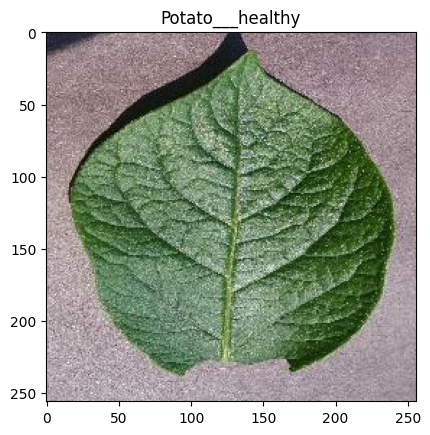

In [10]:
for image_batch, label_batch in dataset.take(1):
    plt.title(class_names[label_batch[0]])
    plt.imshow(image_batch[0].numpy().astype(int))

In [11]:
training_size=0.8
len(dataset)*training_size

54.400000000000006

In [12]:
trained_dataset = dataset.take(54)
len(trained_dataset)

54

In [13]:
test_dataset=dataset.skip(54)
len(test_dataset)

14

In [14]:
validation_size=0.1
len(dataset)*validation_size

6.800000000000001

In [15]:
validation_dataset=test_dataset.take(6)
len(validation_dataset)

6

In [16]:
test_dataset= test_dataset.skip(6)
len(test_dataset)

8

In [17]:
def get_dataset_partitions_tf(dataset, training_split=0.8, validation_split=0.1, testing_split=0.1, shuffle=True, shuffle_size=10000):
    
    dataset_size=len(dataset)
    if shuffle:
        dataset=dataset.shuffle(shuffle_size,seed=7)
    
    training_size = int(training_split*dataset_size)
    validation_size=int(validation_split*dataset_size)
    testing_size=int(testing_split*dataset_size)

    training_dataset=dataset.take(training_size)
    validation_dataset=dataset.skip(training_size).take(validation_size)
    testing_dataset=dataset.skip(training_size).skip(validation_size).take(testing_size)
    
    return training_dataset, validation_dataset, testing_dataset

In [18]:
training_dataset, validation_dataset, testing_dataset = get_dataset_partitions_tf(dataset)

In [19]:
print(len(training_dataset),len(validation_dataset),len(testing_dataset))


54 6 6


In [20]:
training_dataset= training_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
#shuffle is used for randomizing images
#prefetch is used for better performance, when the GPU is used when the CPU is full
validation_dataset= validation_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
testing_dataset= testing_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [21]:
#during processing, if an image has a different size, it is going to be resized
resize_rescale= tf.keras.Sequential([
    tf.keras.layers.Resizing(img_size,img_size),
    tf.keras.layers.Rescaling(1.0/255)
])

In [22]:
#data augmentation is used to create more images than there actually are by applying filters
data_augmentation= tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
])

In [24]:
input_shape=(b_size, img_size, img_size, channels)
num_of_classes=3

model = models.Sequential([
    resize_rescale, 
    data_augmentation,
    
    #convonution layer=
    layers.Conv2D(32,kernel_size=(3,3), activation='relu',input_shape=input_shape),
    #32 is chosen after trying multiple sizes
    #3,3 is the actual filter size
    #'relu' is very fast to compute

    #pooling layer=
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    #flatten to get an array of neurons
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_of_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

In [26]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (32, 12544)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (32, 64)                    │         802,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (32, 3)                     │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 896,323 (3.42 MB)

 Trainable params: 896,323 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    #adam is a famous optimizer
    optimizer='adam',
    
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),

    #'accuracy' is used to track the training process
    metrics=['accuracy']
)

In [28]:
history= model.fit(
    training_dataset,
    epochs=epochs-40,
    batch_size=b_size,
    verbose=1,
    validation_data=validation_dataset
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 777ms/step - accuracy: 0.5434 - loss: 0.8772 - val_accuracy: 0.7917 - val_loss: 0.4973
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 767ms/step - accuracy: 0.8545 - loss: 0.4347 - val_accuracy: 0.8229 - val_loss: 0.5201
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 719ms/step - accuracy: 0.8586 - loss: 0.3525 - val_accuracy: 0.8490 - val_loss: 0.3629
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 747ms/step - accuracy: 0.8707 - loss: 0.2899 - val_accuracy: 0.8854 - val_loss: 0.2846
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 736ms/step - accuracy: 0.9073 - loss: 0.2201 - val_accuracy: 0.9531 - val_loss: 0.1751
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 742ms/step - accuracy: 0.9272 - loss: 0.1837 - val_accuracy: 0.9583 - val_loss: 0.1180
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 44s 812ms/step - accuracy: 0.9415 - loss: 0.1597 - val_accuracy: 0.9479 - val_loss: 0.1078
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 773ms/step - accuracy: 0.9466 - loss: 0.1278 - val_accu

In [29]:
scores = model.evaluate(testing_dataset)

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 267ms/step - accuracy: 0.9106 - loss: 0.2353


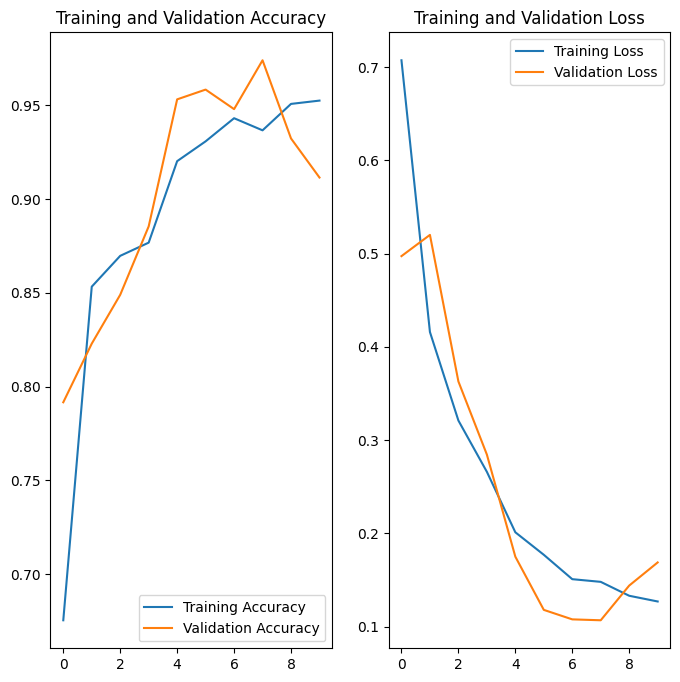

In [30]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs-40)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [38]:
import os

# Verificăm dacă directorul există; dacă nu, îl creăm
if not os.path.exists("../models"):
    os.makedirs("../models")

# Filtrăm elementele care pot fi convertite în întregi
def is_int(s):
    try:
        int(s)
        return True
    except ValueError:
        return False

# Obținem numele directoarelor și fișierelor care pot fi convertite în întregi
valid_entries = [i.split('.')[0] for i in os.listdir("../models") if is_int(i.split('.')[0])]

# Calculăm noua versiune a modelului
model_version = max([int(i) for i in valid_entries] + [0]) + 1
model_dir = f"../models/{model_version}.keras"  # Definim calea directorului modelului

# Salvăm modelul
model.save(model_dir)


